In [1]:
import pandas as pd
import math
import numpy as np
import matplotlib.pyplot as plt

import yfinance as yf
# ignore all warnings
import warnings
warnings.filterwarnings('ignore')

In [5]:
# spy = yf.download(tickers='SPY', interval='1h', period='730d')
# spy.to_csv('spy.csv')
# vixy = yf.download(tickers='VIXY', interval='1h', period='730d')

In [6]:
spy_df = pd.read_csv('spy.csv', usecols=['Adj Close', 'Volume'])
spy_df.rename(columns={'Adj Close': 'price'}, inplace=True)

In [7]:
spy_df['returns'] = np.log(spy_df['price'] / spy_df['price'].shift(1))
spy_df['position'] = np.sign(spy_df['returns'].rolling(5).mean())
spy_df['strategy'] = spy_df['position'].shift(1) * spy_df['returns']

In [8]:
spy_df['signal'] = 0
# Buy signal: position changes from -1 or 0 to 1
spy_df.loc[(spy_df['position'].shift(1) <= 0) & (spy_df['position'] == 1), 'signal'] = 1
# Sell signal: position changes from 1 to -1
spy_df.loc[(spy_df['position'].shift(1) == 1) & (spy_df['position'] == -1), 'signal'] = -1

In [ ]:
spy_df[['returns', 'str']]

In [14]:
cumulative_returns = spy_df[['returns', 'strategy']].dropna().cumsum().apply(np.exp)

# Initial investment amount
initial_investment = 10000

# Calculate final investment values
final_value_returns = initial_investment * cumulative_returns['returns'].iloc[-1]
final_value_strategy = initial_investment * cumulative_returns['strategy'].iloc[-1]

In [16]:
final_value_returns, final_value_strategy

(12825.378288443975, 13206.634160568734)

<AxesSubplot:>

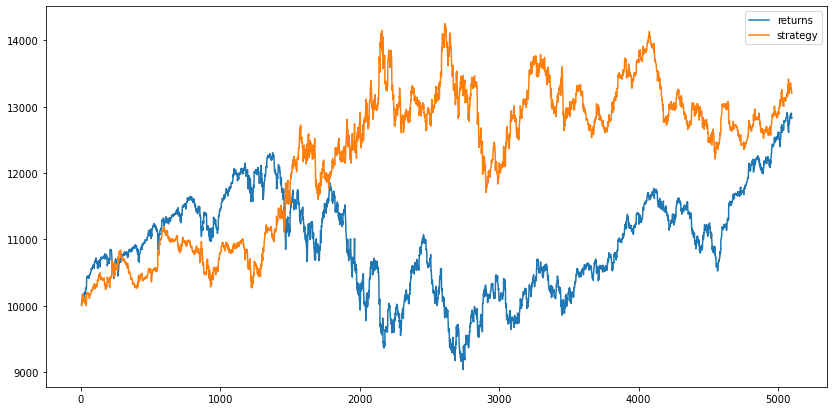

In [19]:
(10000*cumulative_returns).plot(figsize=(14, 7))

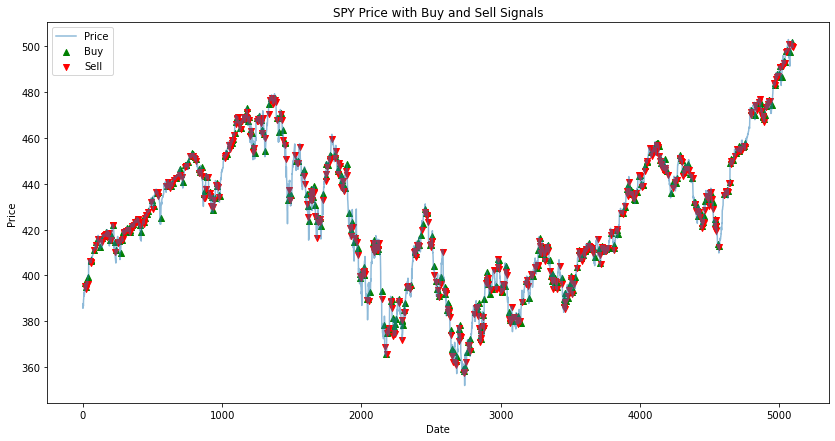

In [11]:
import matplotlib.pyplot as plt

# Assuming spy_df contains 'price', 'signal', and is indexed by date
plt.figure(figsize=(14, 7))  # Set the figure size for better readability

# Plot the price
plt.plot(spy_df.index, spy_df['price'], label='Price', alpha=0.5)

# Plot buy signals
plt.scatter(spy_df[spy_df['signal'] == 1].index, 
            spy_df[spy_df['signal'] == 1]['price'], 
            label='Buy', color='green', marker='^', alpha=1)

# Plot sell signals
plt.scatter(spy_df[spy_df['signal'] == -1].index, 
            spy_df[spy_df['signal'] == -1]['price'], 
            label='Sell', color='red', marker='v', alpha=1)

plt.title('SPY Price with Buy and Sell Signals')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend(loc='best')
plt.show()